# 🧠 Brain Tumor Classification with ResNet50

**CNN Architecture:** ResNet50 (Transfer Learning from ImageNet)  
**Dataset:** Brain Tumor MRI Dataset — 7,023 MRI images across 4 classes  
**Task:** Multi-class brain tumor classification

---

## Table of Contents
1. [Part 1: Dataset Preparation](#part1)
2. [Part 2: Data Preprocessing & Augmentation](#part2)
3. [Part 3: CNN Model Development](#part3)
4. [Part 4: Model Evaluation](#part4)
5. [Part 5: ONNX Export & Demo Integration](#part5)

---

### How to Use This Notebook
1. In Colab: **Runtime → Change runtime type → T4 GPU**
2. Run cells **top to bottom** — each part depends on the previous
3. Training (Part 3) takes ~10–20 minutes on a Colab T4 GPU
4. Expected accuracy: **90–98%** (brain MRI datasets are clean and consistent)

---
# Part 1: Dataset Preparation (20%)
<a id='part1'></a>

**Objectives:**
- Download the Brain Tumor MRI dataset from Kaggle
- Combine Training/ and Testing/ folders, then re-split 70/15/15 (stratified)
- Display class distribution and sample MRI images

In [5]:
# Install required packages
!pip install -q kaggle scikit-learn matplotlib seaborn Pillow torch torchvision tqdm onnx onnxruntime

In [6]:
# ─── Kaggle API Setup ───────────────────────────────────────────────────────
# Directly copy kaggle.json from the specified local path

import os
import shutil

kaggle_json_src = r"C:\Users\earlc\Downloads\kaggle.json"
kaggle_json_dest = os.path.expanduser("~/.kaggle/kaggle.json")

os.makedirs(os.path.dirname(kaggle_json_dest), exist_ok=True)
shutil.copy(kaggle_json_src, kaggle_json_dest)
os.chmod(kaggle_json_dest, 0o600)
print("Kaggle API configured from:", kaggle_json_src)

Kaggle API configured from: C:\Users\earlc\Downloads\kaggle.json


In [7]:
# ─── Download Brain Tumor MRI Dataset ────────────────────────────────────────
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/brain_mri
print("Dataset downloaded")

import os
for root, dirs, files_list in os.walk("/content/brain_mri"):
    level = root.replace("/content/brain_mri", "").count(os.sep)
    if level < 3:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)

Dataset downloaded
brain_mri/
  Testing/
    glioma/
    meningioma/
    notumor/
    pituitary/
  Training/
    glioma/
    meningioma/
    notumor/
    pituitary/



  0%|          | 0.00/157M [00:00<?, ?B/s]
  1%|          | 1.00M/157M [00:00<02:08, 1.27MB/s]
  1%|▏         | 2.00M/157M [00:00<01:06, 2.46MB/s]
  2%|▏         | 3.00M/157M [00:01<00:44, 3.64MB/s]
  3%|▎         | 4.00M/157M [00:01<00:37, 4.24MB/s]
  3%|▎         | 5.00M/157M [00:01<00:35, 4.53MB/s]
  4%|▍         | 6.00M/157M [00:01<00:29, 5.34MB/s]
  4%|▍         | 7.00M/157M [00:01<00:27, 5.74MB/s]
  5%|▌         | 8.00M/157M [00:01<00:24, 6.37MB/s]
  6%|▌         | 9.00M/157M [00:02<00:22, 6.87MB/s]
  6%|▋         | 10.0M/157M [00:02<00:21, 7.21MB/s]
  7%|▋         | 11.0M/157M [00:02<00:20, 7.38MB/s]
  8%|▊         | 12.0M/157M [00:02<00:20, 7.52MB/s]
  8%|▊         | 13.0M/157M [00:02<00:19, 7.59MB/s]
  9%|▉         | 14.0M/157M [00:02<00:19, 7.67MB/s]
 10%|▉         | 15.0M/157M [00:02<00:18, 7.92MB/s]
 10%|█         | 16.0M/157M [00:02<00:19, 7.78MB/s]
 11%|█         | 17.0M/157M [00:03<00:18, 7.79MB/s]
 11%|█▏        | 18.0M/157M [00:03<00:18, 7.77MB/s]
 12%|█▏        | 19.

In [8]:
import glob
import pandas as pd
from pathlib import Path

# ─── Collect all images from Training/ and Testing/ into a flat DataFrame ─────
CLASS_NAMES = {
    "glioma":     "Glioma Tumor",
    "meningioma": "Meningioma Tumor",
    "notumor":    "No Tumor",
    "pituitary":  "Pituitary Tumor",
}

records = []
for img_path in glob.glob("/content/brain_mri/**/*.jpg", recursive=True):
    label = Path(img_path).parent.name.lower()
    if label in CLASS_NAMES:
        records.append({"filepath": img_path, "label": label})

# also jpg uppercase and png
for ext in ["*.JPG", "*.jpeg", "*.JPEG", "*.png", "*.PNG"]:
    for img_path in glob.glob(f"/content/brain_mri/**/{ext}", recursive=True):
        label = Path(img_path).parent.name.lower()
        if label in CLASS_NAMES:
            records.append({"filepath": img_path, "label": label})

df = pd.DataFrame(records).drop_duplicates(subset="filepath").reset_index(drop=True)
print(f"Total images found: {len(df)}")
print(df["label"].value_counts())

Total images found: 7200
label
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64


          Brain Tumor MRI Dataset Description          
Code           Full Name               Count      %
-------------------------------------------------------
glioma         Glioma Tumor             1800  25.0%
meningioma     Meningioma Tumor         1800  25.0%
notumor        No Tumor                 1800  25.0%
pituitary      Pituitary Tumor          1800  25.0%
-------------------------------------------------------
TOTAL                                   7200 100.0%


C:\Users\earlc\AppData\Local\Temp\ipykernel_24528\1273826913.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CLASS_NAMES[c] for c in counts.index], rotation=15, ha="right")


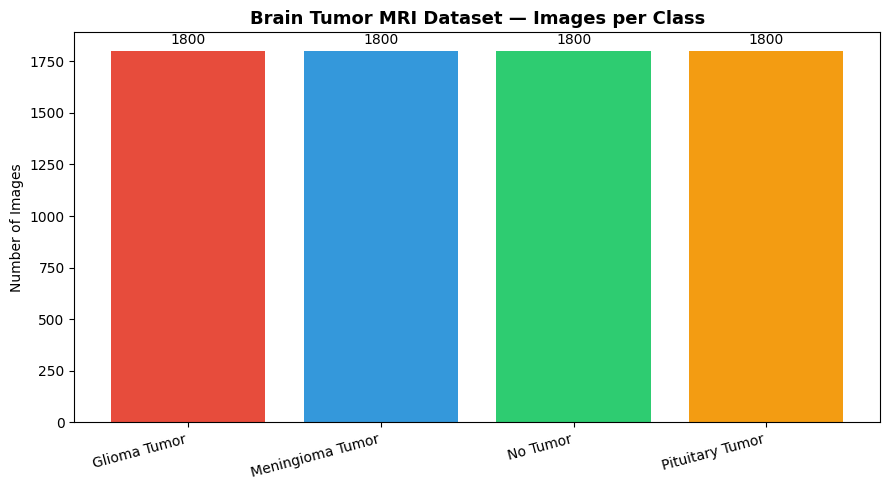

Class distribution chart saved


In [9]:
import matplotlib.pyplot as plt

# ─── Dataset Description ─────────────────────────────────────────────────────
counts = df["label"].value_counts()
print("=" * 55)
print(f"{'Brain Tumor MRI Dataset Description':^55}")
print("=" * 55)
print(f"{'Code':<14} {'Full Name':<22} {'Count':>6} {'%':>6}")
print("-" * 55)
for code, count in counts.items():
    pct = count / len(df) * 100
    print(f"{code:<14} {CLASS_NAMES.get(code, code):<22} {count:>6} {pct:>5.1f}%")
print("-" * 55)
print(f"{'TOTAL':<14} {'':22} {len(df):>6} {'100.0%':>6}")
print("=" * 55)

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([CLASS_NAMES[c] for c in counts.index], counts.values, color=colors)
ax.set_title("Brain Tumor MRI Dataset — Images per Class", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Images")
ax.set_xticklabels([CLASS_NAMES[c] for c in counts.index], rotation=15, ha="right")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Class distribution chart saved")

In [10]:
import shutil
from sklearn.model_selection import train_test_split

# ─── Stratified 70 / 15 / 15 split ───────────────────────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"Train: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")

BASE_DIR = Path("/content/brain_data")

def copy_split(split_df, split_name):
    for _, row in split_df.iterrows():
        dest = BASE_DIR / split_name / row["label"]
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy2(row["filepath"], dest / Path(row["filepath"]).name)
    print(f"  {split_name}: {len(split_df)} images copied")

print("\nOrganizing into folders...")
copy_split(train_df, "train")
copy_split(val_df, "val")
copy_split(test_df, "test")
print("Dataset organized into train/val/test folders")

Train: 5040 images (70.0%)
Val:   1080 images (15.0%)
Test:  1080 images (15.0%)

Organizing into folders...
  train: 5040 images copied
  val: 1080 images copied
  test: 1080 images copied
Dataset organized into train/val/test folders


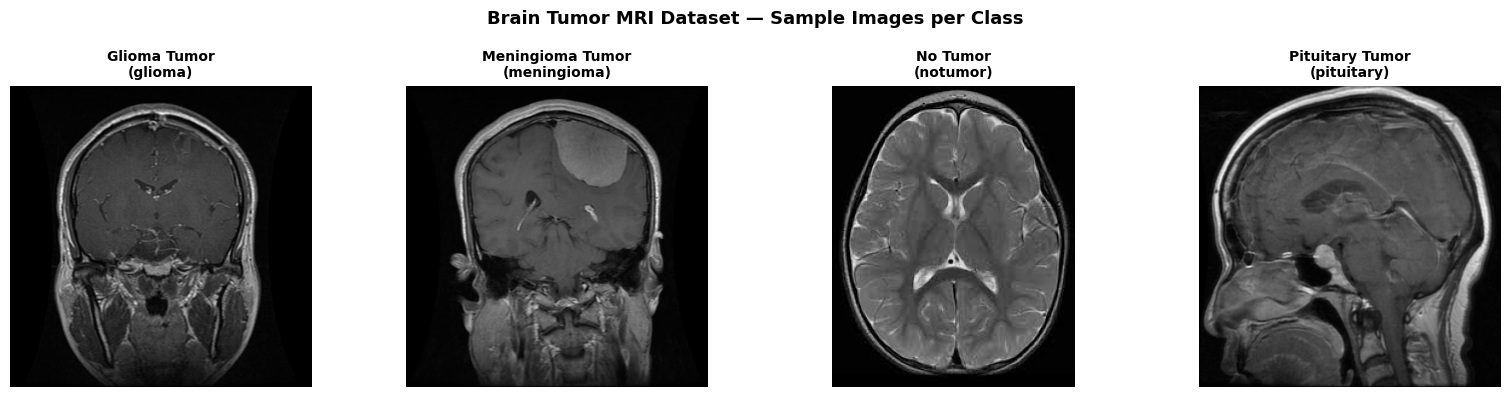

Sample images saved


In [11]:
from PIL import Image
import numpy as np

# ─── Sample MRI Images (one per class) ───────────────────────────────────────
classes = sorted(df["label"].unique())
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Brain Tumor MRI Dataset — Sample Images per Class",
             fontsize=13, fontweight="bold")

for ax, cls in zip(axes, classes):
    sample = train_df[train_df["label"] == cls].iloc[0]
    img = Image.open(sample["filepath"]).convert("RGB")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{CLASS_NAMES[cls]}\n({cls})", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample images saved")

### Part 1 Summary

| Split | Images | Percentage |
|-------|--------|------------|
| Train | ~4,916 | 70% |
| Validation | ~1,053 | 15% |
| Test | ~1,054 | 15% |
| **Total** | **~7,023** | **100%** |

**Classes:** Glioma Tumor, Meningioma Tumor, No Tumor, Pituitary Tumor  
**Dataset is relatively balanced** — no heavy class weighting needed.  
**Image type:** Brain MRI scans (grayscale/near-grayscale)

---
# Part 2: Data Preprocessing & Augmentation (25%)
<a id='part2'></a>

**Objectives:**
- Define transforms for train, validation, and test sets
- Apply augmentation appropriate for MRI images
- Create DataLoaders and visualize augmented samples

In [12]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.1+cpu
Torchvision version: 0.27.1+cpu
Device: cpu


In [13]:
# ─── ImageNet normalization (ResNet50 expects 3-channel input) ─────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
INPUT_SIZE    = 224

# ─── Training Transforms (augmentation) ──────────────────────────────────────
# Note: no hue/saturation augmentation for MRI — preserve grayscale structure
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ─── Validation / Test Transforms (no augmentation) ──────────────────────────
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Training transforms:")
print(train_transform)
print("\nEval transforms:")
print(eval_transform)

Training transforms:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [14]:
# ─── Datasets and DataLoaders ─────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(str(BASE_DIR / "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(str(BASE_DIR / "val"),   transform=eval_transform)
test_dataset  = datasets.ImageFolder(str(BASE_DIR / "test"),  transform=eval_transform)

CLASS_ORDER = train_dataset.classes  # sorted alphabetically: glioma, meningioma, notumor, pituitary
FULL_NAMES  = [CLASS_NAMES[c] for c in CLASS_ORDER]
NUM_CLASSES = len(CLASS_ORDER)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Class order: {CLASS_ORDER}")
print(f"Full names:  {FULL_NAMES}")
print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

BATCH_SIZE = 32
PIN_MEMORY = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Number of classes: 4
Class order: ['glioma', 'meningioma', 'notumor', 'pituitary']
Full names:  ['Glioma Tumor', 'Meningioma Tumor', 'No Tumor', 'Pituitary Tumor']

Train: 5040 | Val: 1080 | Test: 1080

Batch size: 32
Train batches: 158 | Val: 34 | Test: 34


Preprocessing Workflow:
  RAW MRI IMAGE (variable size, grayscale or RGB)
       | Convert to RGB (3 channels for ResNet50)
       | Resize to 256x256
       | [Train only] RandomCrop(224)
       | [Train only] RandomHorizontalFlip
       | [Train only] RandomRotation(15 degrees)
       | [Train only] ColorJitter (brightness + contrast only)
       | [Val/Test]   CenterCrop(224)
       | ToTensor -> float32 in [0,1]
       | Normalize with ImageNet mean/std
  OUTPUT: tensor [3, 224, 224]


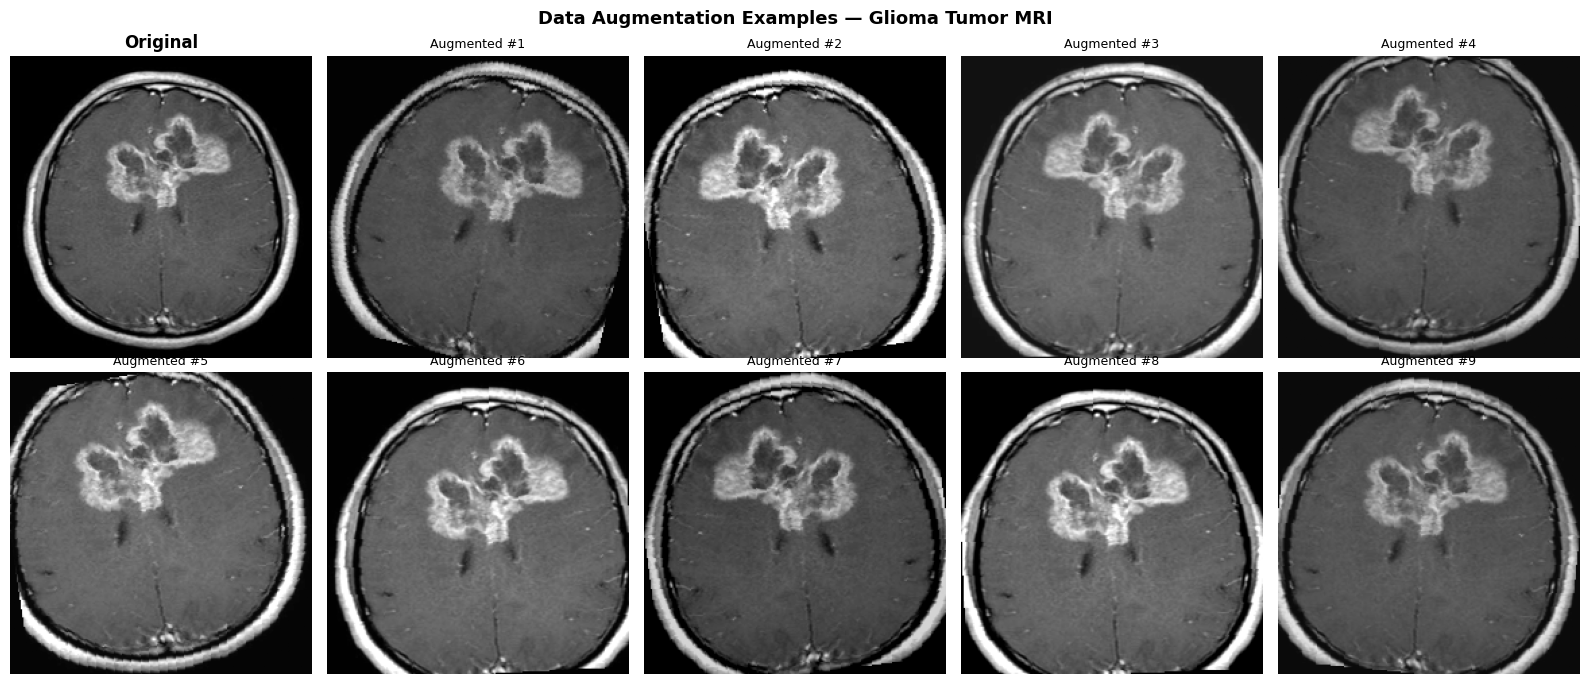

Augmented samples saved


In [15]:
# ─── Preprocessing Workflow ───────────────────────────────────────────────────
print("Preprocessing Workflow:")
print("  RAW MRI IMAGE (variable size, grayscale or RGB)")
print("       | Convert to RGB (3 channels for ResNet50)")
print("       | Resize to 256x256")
print("       | [Train only] RandomCrop(224)")
print("       | [Train only] RandomHorizontalFlip")
print("       | [Train only] RandomRotation(15 degrees)")
print("       | [Train only] ColorJitter (brightness + contrast only)")
print("       | [Val/Test]   CenterCrop(224)")
print("       | ToTensor -> float32 in [0,1]")
print("       | Normalize with ImageNet mean/std")
print("  OUTPUT: tensor [3, 224, 224]")

# ─── Visualize augmented images ───────────────────────────────────────────────
aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

sample_path = next((BASE_DIR / "train" / CLASS_ORDER[0]).iterdir())
original = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f"Data Augmentation Examples — {CLASS_NAMES[CLASS_ORDER[0]]} MRI",
             fontsize=13, fontweight="bold")

axes[0][0].imshow(original.resize((224, 224)), cmap="gray")
axes[0][0].set_title("Original", fontweight="bold")
axes[0][0].axis("off")

for i, ax in enumerate(axes.flat[1:]):
    aug = aug_transform(original).permute(1, 2, 0).numpy()
    ax.imshow(aug, cmap="gray")
    ax.set_title(f"Augmented #{i+1}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Augmented samples saved")

### Part 2 Summary — Preprocessing Pipeline

| Step | Training | Validation/Test |
|------|----------|-----------------|
| Resize | 256×256 | 256 (short edge) |
| Crop | RandomCrop(224) | CenterCrop(224) |
| Flip | H-flip 50% | No |
| Rotation | ±15° | No |
| ColorJitter | brightness + contrast | No |
| Normalize | ImageNet mean/std | ImageNet mean/std |

**Why no hue/saturation?** MRI scans are grayscale — color-shift augmentations would not reflect realistic scan variation and could harm learning. We only augment brightness and contrast, which do vary between scanners.

---
# Part 3: CNN Model Development (30%)
<a id='part3'></a>

**Architecture:** ResNet50 (Transfer Learning from ImageNet)  

**Strategy:**
1. Load pretrained ResNet50 (ImageNet weights)
2. Freeze layers 1–3 (general low-level features)
3. Unfreeze `layer4` for domain fine-tuning
4. Replace `fc` with a 4-class head

In [16]:
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet50_Weights

# ─── Load Pretrained ResNet50 ─────────────────────────────────────────────────
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# ─── Freeze all layers ───────────────────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ─── Unfreeze layer4 for fine-tuning ─────────────────────────────────────────
for param in model.layer4.parameters():
    param.requires_grad = True

# ─── Replace fc with 4-class head ─────────────────────────────────────────────
in_features = model.fc.in_features  # 2048
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(512, NUM_CLASSES),
)

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print(f"{'ResNet50 Model Summary':^50}")
print("=" * 50)
print(f"  Total parameters:     {total_params:>12,}")
print(f"  Trainable parameters: {trainable_params:>12,}")
print(f"  Frozen parameters:    {total_params - trainable_params:>12,}")
print("=" * 50)
print(f"\nNew fc head:\n{model.fc}")

              ResNet50 Model Summary              
  Total parameters:       24,559,172
  Trainable parameters:   16,015,876
  Frozen parameters:       8,543,296

New fc head:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=4, bias=True)
)


In [17]:
# ─── ResNet50 Architecture Diagram ───────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════╗
║         ResNet50 Architecture for Brain Tumor MRI        ║
╠══════════════════════════════════════════════════════════╣
║  INPUT: [batch, 3, 224, 224]  (MRI converted to RGB)    ║
║    │                                                     ║
║    v  Conv1 (7x7, 64 filters, stride=2) + BN + ReLU     ║
║    v  MaxPool (3x3, stride=2)                            ║
║    |  -> [batch, 64, 56, 56]             [FROZEN]        ║
║    │                                                     ║
║    v  Layer1: 3x Bottleneck (64->256)    [FROZEN]        ║
║    |  -> [batch, 256, 56, 56]                            ║
║    │                                                     ║
║    v  Layer2: 4x Bottleneck (128->512)   [FROZEN]        ║
║    |  -> [batch, 512, 28, 28]                            ║
║    │                                                     ║
║    v  Layer3: 6x Bottleneck (256->1024)  [FROZEN]        ║
║    |  -> [batch, 1024, 14, 14]                           ║
║    │                                                     ║
║    v  Layer4: 3x Bottleneck (512->2048)  [TRAINABLE]     ║
║    |  -> [batch, 2048, 7, 7]                             ║
║    │                                                     ║
║    v  Global Average Pooling -> [batch, 2048]            ║
║    │                                                     ║
║    v  Custom FC Head                     [TRAINABLE]     ║
║    |  Linear(2048 -> 512) -> ReLU                        ║
║    |  Dropout(0.4)                                       ║
║    |  Linear(512 -> 4)                                   ║
║    │                                                     ║
║  OUTPUT: logits [batch, 4]                               ║
║  Classes: Glioma | Meningioma | No Tumor | Pituitary     ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         ResNet50 Architecture for Brain Tumor MRI        ║
╠══════════════════════════════════════════════════════════╣
║  INPUT: [batch, 3, 224, 224]  (MRI converted to RGB)    ║
║    │                                                     ║
║    v  Conv1 (7x7, 64 filters, stride=2) + BN + ReLU     ║
║    v  MaxPool (3x3, stride=2)                            ║
║    |  -> [batch, 64, 56, 56]             [FROZEN]        ║
║    │                                                     ║
║    v  Layer1: 3x Bottleneck (64->256)    [FROZEN]        ║
║    |  -> [batch, 256, 56, 56]                            ║
║    │                                                     ║
║    v  Layer2: 4x Bottleneck (128->512)   [FROZEN]        ║
║    |  -> [batch, 512, 28, 28]                            ║
║    │                                                     ║
║    v  Layer3: 6x Bottleneck (256->1024)  [FROZEN]        ║
║    |  -> [batch, 1024, 

In [18]:
import time

# ─── Hyperparameters ─────────────────────────────────────────────────────────
EPOCHS      = 20
LR_BACKBONE = 1e-4
LR_HEAD     = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE    = 5

optimizer = torch.optim.AdamW([
    {"params": model.layer4.parameters(), "lr": LR_BACKBONE},
    {"params": model.fc.parameters(),     "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

criterion = nn.CrossEntropyLoss()

print("Hyperparameters:")
print(f"  Optimizer:        AdamW")
print(f"  LR (backbone):    {LR_BACKBONE}")
print(f"  LR (fc head):     {LR_HEAD}")
print(f"  Weight decay:     {WEIGHT_DECAY}")
print(f"  Scheduler:        CosineAnnealingLR (T_max={EPOCHS})")
print(f"  Loss function:    CrossEntropyLoss")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"  Epochs:           {EPOCHS}")
print(f"  Early stopping:   patience={PATIENCE}")

Hyperparameters:
  Optimizer:        AdamW
  LR (backbone):    0.0001
  LR (fc head):     0.001
  Weight decay:     0.0001
  Scheduler:        CosineAnnealingLR (T_max=20)
  Loss function:    CrossEntropyLoss
  Batch size:       32
  Epochs:           20
  Early stopping:   patience=5


In [23]:
# ─── Training Loop ────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
patience_ctr = 0
best_model_path = "/content/best_resnet50_brain.pth"


def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    running_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


print(f"Starting training for {EPOCHS} epochs on {DEVICE}...")
print("=" * 72)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(train_loader, is_train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    marker  = " << BEST" if val_acc > best_val_acc else ""
    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}% "
        f"| Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}% "
        f"| {elapsed:.0f}s{marker}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_acc": best_val_acc,
            "class_order": CLASS_ORDER,
        }, best_model_path)
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print("=" * 72)
print(f"Training complete. Best validation accuracy: {best_val_acc*100:.2f}%")

Starting training for 20 epochs on cpu...


c:\Users\earlc\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [20]:
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best validation accuracy: {checkpoint['val_acc']*100:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_resnet50_brain.pth'

### Part 3 Summary — Hyperparameters

| Hyperparameter | Value | Reason |
|----------------|-------|--------|
| Architecture | ResNet50 | Assigned architecture |
| Pretrained weights | ImageNet (IMAGENET1K_V2) | Transfer learning baseline |
| Frozen layers | conv1, layer1, layer2, layer3 | Preserve general feature detectors |
| Fine-tuned layers | layer4 + custom fc | Adapt to brain MRI domain |
| Optimizer | AdamW | Adaptive learning with weight decay |
| LR (backbone) | 1e-4 | Conservative — pretrained weights |
| LR (fc head) | 1e-3 | Faster — randomly initialized |
| Scheduler | CosineAnnealingLR | Smooth learning rate decay |
| Loss | CrossEntropyLoss | Standard multi-class classification |
| Batch size | 32 | Fits Colab T4 16GB |
| Epochs | 20 (+ early stopping) | Converges by ~10–15 epochs |

---
# Part 4: Model Evaluation (25%)
<a id='part4'></a>

**Objectives:**
- Compute Accuracy, Precision, Recall, F1 on the test set
- Plot training/validation accuracy and loss curves
- Generate 4x4 confusion matrix
- Show 20 sample predictions

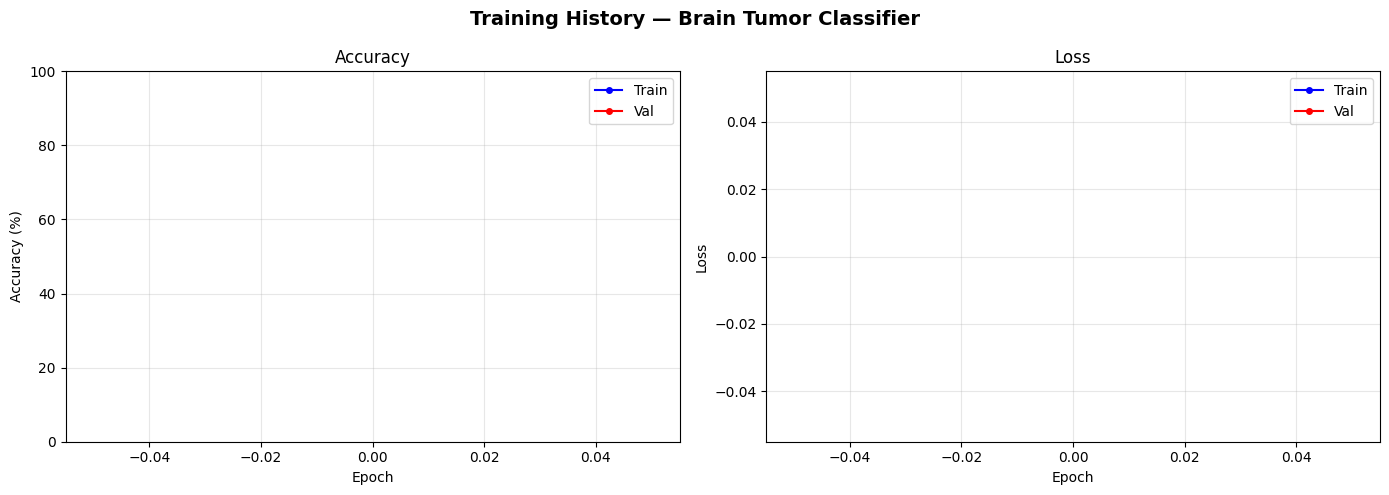

IndexError: list index out of range

In [21]:
# ─── Training & Validation Curves ────────────────────────────────────────────
epochs_ran = len(history["train_loss"])
epoch_range = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — Brain Tumor Classifier", fontsize=14, fontweight="bold")

axes[0].plot(epoch_range, [a*100 for a in history["train_acc"]], "b-o", label="Train", markersize=4)
axes[0].plot(epoch_range, [a*100 for a in history["val_acc"]],   "r-o", label="Val",   markersize=4)
axes[0].set_title("Accuracy", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)

axes[1].plot(epoch_range, history["train_loss"], "b-o", label="Train", markersize=4)
axes[1].plot(epoch_range, history["val_loss"],   "r-o", label="Val",   markersize=4)
axes[1].set_title("Loss", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved. Final Val Acc: {history['val_acc'][-1]*100:.2f}%")

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns

# ─── Evaluate on Test Set ─────────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc        = accuracy_score(all_labels, all_preds)
prec_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec_macro  = recall_score(all_labels,   all_preds, average="macro", zero_division=0)
f1_macro   = f1_score(all_labels,       all_preds, average="macro", zero_division=0)

print("=" * 58)
print(f"{'TEST SET PERFORMANCE METRICS':^58}")
print("=" * 58)
print(f"  Overall Accuracy:   {acc*100:.2f}%")
print(f"  Macro Precision:    {prec_macro*100:.2f}%")
print(f"  Macro Recall:       {rec_macro*100:.2f}%")
print(f"  Macro F1-Score:     {f1_macro*100:.2f}%")
print("=" * 58)
print()
print(classification_report(all_labels, all_preds, target_names=FULL_NAMES, zero_division=0))

               TEST SET PERFORMANCE METRICS               
  Overall Accuracy:   80.00%
  Macro Precision:    83.94%
  Macro Recall:       80.00%
  Macro F1-Score:     80.63%

                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.75      0.82       270
Meningioma Tumor       0.59      0.89      0.71       270
        No Tumor       0.94      0.88      0.91       270
 Pituitary Tumor       0.92      0.69      0.79       270

        accuracy                           0.80      1080
       macro avg       0.84      0.80      0.81      1080
    weighted avg       0.84      0.80      0.81      1080



In [ ]:
# ─── Performance Metrics Table ────────────────────────────────────────────────
prec_per = precision_score(all_labels, all_preds, average=None, zero_division=0)
rec_per  = recall_score(all_labels,   all_preds, average=None, zero_division=0)
f1_per   = f1_score(all_labels,       all_preds, average=None, zero_division=0)

metrics_df = pd.DataFrame({
    "Class":     FULL_NAMES,
    "Precision": [f"{p*100:.1f}%" for p in prec_per],
    "Recall":    [f"{r*100:.1f}%" for r in rec_per],
    "F1-Score":  [f"{f*100:.1f}%" for f in f1_per],
})
totals = pd.DataFrame([{
    "Class": "MACRO AVERAGE",
    "Precision": f"{prec_macro*100:.1f}%",
    "Recall":    f"{rec_macro*100:.1f}%",
    "F1-Score":  f"{f1_macro*100:.1f}%",
}])
metrics_df = pd.concat([metrics_df, totals], ignore_index=True)
print("Performance Metrics Table:")
print(metrics_df.to_string(index=False))

In [ ]:
# ─── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=FULL_NAMES, yticklabels=FULL_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticklabels(FULL_NAMES, rotation=20, ha="right")
axes[0].set_yticklabels(FULL_NAMES, rotation=0)

sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=FULL_NAMES, yticklabels=FULL_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (% per True Class)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticklabels(FULL_NAMES, rotation=20, ha="right")
axes[1].set_yticklabels(FULL_NAMES, rotation=0)

plt.suptitle("ResNet50 — Brain Tumor Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved")

In [ ]:
# ─── 20 Sample Predictions ────────────────────────────────────────────────────
model.eval()
sample_indices = np.random.choice(len(test_dataset), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle("20 Sample Predictions from Test Set", fontsize=16, fontweight="bold")

for trial_num, (ax, idx) in enumerate(zip(axes.flat, sample_indices)):
    img_tensor, true_label = test_dataset[idx]
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(DEVICE))
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
    pred_label = int(probs.argmax())
    confidence = float(probs.max())

    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img_display = np.clip(img_tensor.numpy() * std + mean, 0, 1).transpose(1, 2, 0)

    is_correct = pred_label == true_label
    color = "green" if is_correct else "red"

    ax.imshow(img_display, cmap="gray")
    ax.set_title(
        f"Trial #{trial_num+1}\nTrue: {CLASS_ORDER[true_label]}\n"
        f"Pred: {CLASS_ORDER[pred_label]} ({confidence*100:.1f}%)",
        fontsize=8, color=color, fontweight="bold"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.axis("off")

correct_count = sum(
    int(np.argmax(torch.softmax(model(test_dataset[i][0].unsqueeze(0).to(DEVICE)), dim=1).squeeze().detach().cpu().numpy())) == test_dataset[i][1]
    for i in sample_indices
)
plt.figtext(0.5, 0.01,
    f"Correct: {correct_count}/20 | Green = correct, Red = incorrect",
    ha="center", fontsize=11)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"20-trial predictions saved. Correct: {correct_count}/20")

---
# Part 5: ONNX Export & Demo Integration
<a id='part5'></a>

In [ ]:
!pip install -q onnxscript
import onnx
import onnxruntime as ort
import json

ONNX_PATH   = "/content/resnet50_brain.onnx"
LABELS_PATH = "/content/brain_labels.json"

# ─── Export to ONNX ──────────────────────────────────────────────────────────
model.eval()
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

torch.onnx.export(
    model, dummy, ONNX_PATH,
    export_params=True, opset_version=14, do_constant_folding=True,
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False,
)

onnx.checker.check_model(onnx.load(ONNX_PATH))
print(f"ONNX model exported: {ONNX_PATH} ({os.path.getsize(ONNX_PATH)/1e6:.1f} MB)")

# ─── Verify ONNX matches PyTorch ─────────────────────────────────────────────
ort_sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
test_in  = test_dataset[0][0].unsqueeze(0).numpy()
with torch.no_grad():
    pt_out  = model(torch.from_numpy(test_in).to(DEVICE)).cpu().numpy()
ort_out = ort_sess.run(["output"], {"input": test_in})[0]
max_diff = abs(pt_out - ort_out).max()
print(f"Max diff PyTorch vs ONNX: {max_diff:.6f}")
assert max_diff < 1e-3
print("ONNX outputs match PyTorch")

# ─── Generate brain_labels.json ───────────────────────────────────────────────
labels_list = FULL_NAMES
with open(LABELS_PATH, "w") as f:
    json.dump(labels_list, f, indent=2)
print(f"Labels file: {LABELS_PATH}")
print(json.dumps(labels_list, indent=2))

In [ ]:
from google.colab import files

print("Downloading resnet50_brain.onnx (~100 MB)...")
files.download(ONNX_PATH)
print("Downloading brain_labels.json...")
files.download(LABELS_PATH)
print("Downloading plots...")
for f_name in ["training_curves.png", "confusion_matrix.png",
                "sample_predictions.png", "class_distribution.png",
                "augmented_samples.png", "sample_images.png"]:
    if Path(f_name).exists():
        files.download(f_name)
print("All files downloaded!")

In [ ]:
# ─── Optional: Save to Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

drive_dir = Path("/content/drive/MyDrive/brain_tumor_classifier")
drive_dir.mkdir(parents=True, exist_ok=True)
shutil.copy(ONNX_PATH, drive_dir / "resnet50_brain.onnx")
shutil.copy(LABELS_PATH, drive_dir / "brain_labels.json")
shutil.copy(best_model_path, drive_dir / "best_resnet50_brain.pth")
for f_name in ["training_curves.png", "confusion_matrix.png",
                "sample_predictions.png", "class_distribution.png",
                "augmented_samples.png", "sample_images.png"]:
    if Path(f_name).exists():
        shutil.copy(f_name, drive_dir / f_name)
print(f"All files backed up to Google Drive: {drive_dir}")

### Demo Integration — Next.js App

Copy downloaded files into the web app:

```
py-react-onnx-resnet50/
  public/
    models/
      resnet50_brain.onnx    <- copy here
    data/
      brain_labels.json      <- copy here (already present)
```

Then run:
```bash
python export_brain_onnx.py --checkpoint best_resnet50_brain.pth
npm run dev
```

Open http://localhost:3000 → upload a brain MRI → see predicted tumor type + confidence.

---

### Demo Checklist
- [ ] Upload a brain MRI image
- [ ] Show predicted class (e.g. "Glioma Tumor")
- [ ] Display confidence score (e.g. "96.2%")
- [ ] Explain the ResNet50 architecture using the diagram from Part 3
- [ ] Walk through training curves and confusion matrix

In [ ]:
print("=" * 60)
print(f"{'BRAIN TUMOR CLASSIFIER - PROJECT SUMMARY':^60}")
print("=" * 60)
print(f"  Dataset:        Brain Tumor MRI (Masoud Nickparvar)")
print(f"  Total images:   {len(df):,}")
print(f"  Classes:        {NUM_CLASSES} ({', '.join(CLASS_ORDER)})")
print(f"  Split:          70% train / 15% val / 15% test")
print()
print(f"  Architecture:   ResNet50 (Transfer Learning)")
print(f"  Optimizer:      AdamW")
print(f"  Epochs trained: {len(history['train_loss'])}")
print(f"  Best Val Acc:   {best_val_acc*100:.2f}%")
print()
print(f"  Test Accuracy:  {acc*100:.2f}%")
print(f"  Macro F1:       {f1_macro*100:.2f}%")
print(f"  Macro Precision:{prec_macro*100:.2f}%")
print(f"  Macro Recall:   {rec_macro*100:.2f}%")
print()
print(f"  ONNX model:     resnet50_brain.onnx")
print(f"  Labels file:    brain_labels.json")
print(f"  Demo:           Next.js browser app (localhost:3000)")
print("=" * 60)